In [266]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,Lasso, Ridge, LogisticRegression

In [267]:
df = pd.read_csv("C:/Users/Laptop Links/Desktop/AI(ML&DL)/Datasets/student_mental_health_burnout.csv")
df

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,249996,24,Female,BSc,3rd,1.6,8.2,11.3,Medium,9,9,5,3,10,2.0,Good,54.2,7.82,Good,Low
149996,249997,25,Male,BCA,3rd,9.9,4.8,1.6,High,10,3,10,10,2,0.1,Poor,53.6,7.19,Average,High
149997,249998,22,Male,BTech,1st,1.4,4.4,4.6,High,10,8,6,4,7,1.6,Good,90.7,9.78,Average,High
149998,249999,19,Male,BSc,3rd,1.5,4.3,1.1,Medium,8,6,5,7,4,1.1,Average,83.9,9.88,Average,Medium


In [268]:
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


Section 1: Data Understanding

1. How many rows and columns are present in the dataset? Based on the sample provided,
what is the total number of unique students?

In [269]:
df.shape

(150000, 20)

In [270]:
df["course"].unique()

<StringArray>
['BTech', 'BCA', 'BSc', 'MBA', 'MCA', 'BBA']
Length: 6, dtype: str

2. Which columns have missing values? Examine the provided sample are there any visible
missing entries? How would you systematically check for missing values across the
entire dataset?

In [271]:
df.isnull().sum()

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

3. Identify all categorical, numerical, and ordinal columns in the dataset. Justify your
classification for each.


In [272]:
df.columns
# Numerical columns
# 'student_id', 'age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'anxiety_score', 'depression_score',
#  'academic_pressure_score', 'financial_stress_score', 'social_support_score', 'physical_activity_hours' , 'attendance_percentage','cgpa'

# Categorical colmuns
# 'gender', 'course'

# Ordinal columns
# 'year' , 'stress_level' , 'sleep_quality' , 'internet_quality' , 'burnout_level'

Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='str')

4. Calculate the mean, median, and standard deviation for cgpa, daily_study_hours, and
screen_time_hours.


In [273]:
print(df["cgpa"].mean())
print(df["cgpa"].median())
print(df["cgpa"].std())
print(df['daily_study_hours'].mean())
print(df['daily_study_hours'].median())
print(df['daily_study_hours'].std())
print(df["screen_time_hours"].mean())
print(df["screen_time_hours"].median())
print(df["screen_time_hours"].std())

6.997389000000001
6.99
1.7321799909350664
5.507868666666667
5.5
2.5955918781785035
6.502819333333333
6.5
3.178948236357242


5. Which gender has the highest average anxiety_score? Provide the exact value.


In [274]:
df.groupby("gender")["anxiety_score"].mean()
# Male gender has the highest average anxiety score = 5.502862

gender
Female    5.488237
Male      5.502862
Other     5.490629
Name: anxiety_score, dtype: float64

6. List all unique course values and calculate the proportion of students in each course.


In [275]:
df["course"].unique()

<StringArray>
['BTech', 'BCA', 'BSc', 'MBA', 'MCA', 'BBA']
Length: 6, dtype: str

<Axes: title={'center': 'Students % in each course'}>

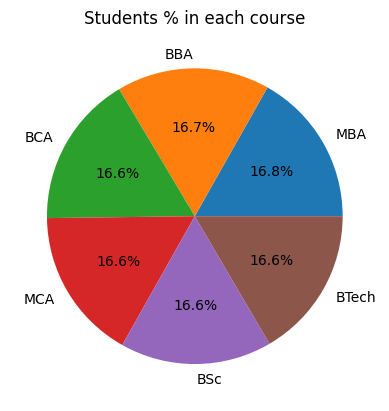

In [276]:
df["course"].value_counts().plot(kind="pie",autopct="%1.1f%%",title="Students % in each course")

7. What is the distribution of year of study? How many students are in each academic
year?


<Axes: title={'center': 'Number of student % in each year'}>

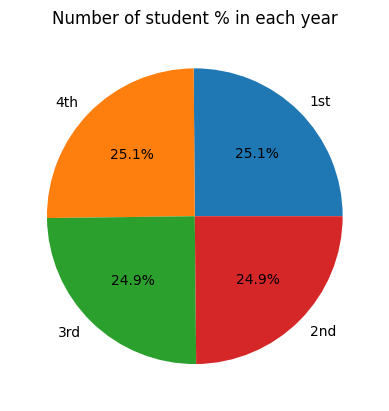

In [277]:
df["year"].value_counts().plot(kind="pie",autopct="%1.1f%%",title="Number of student % in each year")

8. Compare the average cgpa between students with sleep_quality = "Good" vs "Poor".

In [278]:
df.groupby("sleep_quality")["cgpa"].mean()

sleep_quality
Average    6.991159
Good       7.013745
Poor       6.987189
Name: cgpa, dtype: float64

9. What is the correlation between daily_study_hours and cgpa in the sample?

Text(0.5, 1.0, 'Correlation b/w daily_study_hours and cgpa')

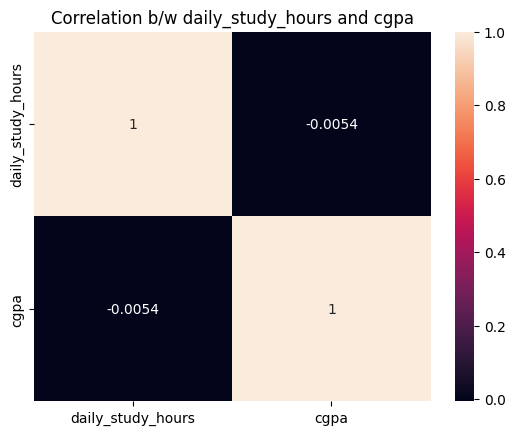

In [279]:
corr = df[["daily_study_hours","cgpa"]].corr()
sns.heatmap(corr,annot=True)
plt.title("Correlation b/w daily_study_hours and cgpa")

10. Which stress_level category appears most frequently, and what is its percentage?


<Axes: title={'center': 'Stress level'}>

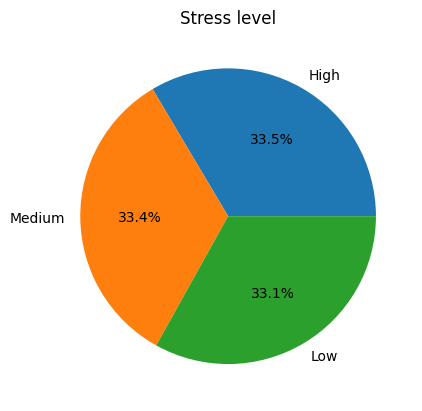

In [280]:
df["stress_level"].value_counts().plot(kind="pie",autopct="%1.1f%%",title="Stress level")
# High stress level category appears the most = 33.5

Section 2: Data Cleaning & Preprocessing (Complex)

Missing Value Handling

a. How many rows contain at least one NaN value?


In [281]:
df.isnull().sum()
# There no null values in the dataset

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

b. If missing values exist, what strategies would you use for numerical columns vs categorical
columns? Provide at least two different imputation methods for each type with justification.


In [282]:
# Numerical columns: Missing values can be handled using mean imputation, median imputation, and more advanced methods like interpolation, 
# regression imputation, or KNN imputation.

# Categorical columns: Missing values can be handled using mode imputation, adding a new category (e.g., “Unknown”), and
# probability/frequency-based imputation.

c. Are there any rows with all NaN values? How would you handle them?


In [283]:
# There are no nan values in this dataset.
# Numerical columns: Missing values can be handled using mean imputation, median imputation, and more advanced methods like interpolation, 
# regression imputation, or KNN imputation.

# Categorical columns: Missing values can be handled using mode imputation, adding a new category (e.g., “Unknown”), and
# probability/frequency-based imputation.

Duplicate Detection

a. How many duplicate rows exist? What columns would you consider to define a duplicate
record?

In [284]:
df.duplicated().sum()
# There are no duplicate values in this dataset.

np.int64(0)

b. If duplicates are found, what effect might keeping them have on logistic regression model
performance?


In [285]:
# If duplicate records are kept in the dataset, they can negatively affect the performance of a logistic regression model. Duplicates give extra weight 
# to certain observations, causing the model to become biased toward those repeated patterns. This can lead to overfitting, where the model learns specific 
# data points too well instead of generalizing to new data. As a result, the model may show artificially high accuracy during training but perform poorly 
# on unseen data.

Outlier Detection & Treatment

a. Use the IQR method to detect outliers. How many outliers exist in each?

In [286]:
cols = ['student_id', 'age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 'anxiety_score', 
        'depression_score', 'academic_pressure_score', 'financial_stress_score', 'social_support_score', 
        'physical_activity_hours' , 'attendance_percentage','cgpa']

outlier_counts = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

# Display number of outliers per column
for col, count in outlier_counts.items():
    print(f"{col}: {count} outliers")

student_id: 0 outliers
age: 0 outliers
daily_study_hours: 0 outliers
daily_sleep_hours: 0 outliers
screen_time_hours: 0 outliers
anxiety_score: 0 outliers
depression_score: 0 outliers
academic_pressure_score: 0 outliers
financial_stress_score: 0 outliers
social_support_score: 0 outliers
physical_activity_hours: 0 outliers
attendance_percentage: 0 outliers
cgpa: 0 outliers


b. Apply two different outlier treatment methods (iqr and transformation) and explain which you
would choose for logistic regression and why.


In [287]:
# Two common outlier treatments are the IQR method and data transformation. The IQR method detects outliers and 
# removes or caps them, while transformations (like log or square root) reduce the impact of extreme values without 
# removing data. For logistic regression, transformations are preferred because they preserve all observations and 
# reduce outlier influence, helping the model generalize better.

Encoding Categorical Variables


a. Identify all categorical columns and explain why they need encoding.


In [288]:
# Gender and Course are categorical columns.
# They need encoding because models like logistic regression can only work with numbers, not text. Encoding converts 
# categorical labels into numerical values so the model can process them.

b. Apply both One-Hot Encoding and Label Encoding to appropriate columns. Compare the
results.


In [289]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['course'] = le.fit_transform(df['course'])

In [290]:
df_onehot = pd.get_dummies(df, columns=['gender', 'course'], drop_first=True)

In [291]:
# Comparison
# gender has only two categories → Label Encoding works fine and keeps it simple.
# course may have multiple categories → One-Hot Encoding is better, because Label Encoding would incorrectly imply an 
# order between courses.

c. For sleep_quality (Average, Good, Poor) and stress_level (Low, Medium, High), why is
ordinal encoding more appropriate than one-hot encoding? Implement it.


In [292]:
from sklearn.preprocessing import OrdinalEncoder

# Define the order for each column
sleep_order = ['Poor', 'Average', 'Good']
stress_order = ['Low', 'Medium', 'High']

encoder = OrdinalEncoder(categories=[sleep_order, stress_order])

# Apply to the columns
df[['sleep_quality', 'stress_level']] = encoder.fit_transform(df[['sleep_quality', 'stress_level']])

# Check result
print(df[['sleep_quality', 'sleep_quality', 'stress_level', 'stress_level']].head())

   sleep_quality  sleep_quality  stress_level  stress_level
0            1.0            1.0           2.0           2.0
1            0.0            0.0           2.0           2.0
2            2.0            2.0           0.0           0.0
3            0.0            0.0           2.0           2.0
4            2.0            2.0           2.0           2.0


In [293]:
# For sleep_quality (Average, Good, Poor) and stress_level (Low, Medium, High`), ordinal encoding is more appropriate 
# because the categories have a natural order. One-hot encoding would treat them as unrelated, ignoring that “High” 
# stress is more than “Medium” and “Medium” is more than “Low,” which can reduce the model’s ability to learn 
# meaningful patterns. Ordinal encoding preserves this order by assigning numbers that reflect the ranking.

Feature Scaling

a. Explain why standardization (Z-score) is recommended for logistic regression.

In [294]:
# Standardization (Z-score) is recommended for logistic regression because it scales numerical features to have a mean 
# of 0 and a standard deviation of 1, ensuring that all features contribute equally to the model. Without 
# standardization, features with larger ranges can dominate the optimization process, causing slower convergence or 
# unstable coefficient estimates. Standardization also helps when using regularization (like L1 or L2), as it ensures 
# the penalty is applied fairly across all features. Overall, it improves model performance, stability, and 
# interpretability.

b. Apply StandardScaler to all numerical features. Show the mean and standard deviation of
scaled features to verify

In [295]:
numerical_cols = ['student_id', 'age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 
                  'anxiety_score', 'depression_score', 'academic_pressure_score', 'financial_stress_score', 
                  'social_support_score', 'physical_activity_hours', 'attendance_percentage','cgpa']

# Initialize scaler
scaler = StandardScaler()

# Fit and transform
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Verify mean and std
scaled_stats = pd.DataFrame({
    'mean': df_scaled[numerical_cols].mean(),
    'std': df_scaled[numerical_cols].std()
})

print(scaled_stats)

                                 mean       std
student_id               4.850638e-17  1.000003
age                      4.244309e-17  1.000003
daily_study_hours       -1.139237e-16  1.000003
daily_sleep_hours        3.149125e-16  1.000003
screen_time_hours        8.801256e-17  1.000003
anxiety_score           -2.576902e-17  1.000003
depression_score         1.256240e-16  1.000003
academic_pressure_score  7.152797e-17  1.000003
financial_stress_score   8.867573e-17  1.000003
social_support_score    -1.529088e-16  1.000003
physical_activity_hours  1.688250e-16  1.000003
attendance_percentage    7.707020e-16  1.000003
cgpa                    -5.580129e-16  1.000003


Data Type Validation

After preprocessing, verify that all columns have appropriate data types for modeling. Convert
any incorrectly typed columns.


In [296]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  int64  
 3   course                   150000 non-null  int64  
 4   year                     150000 non-null  str    
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  float64
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  physical_activi

In [297]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='str')

In [298]:
cols = ['age', 'daily_study_hours', 'daily_sleep_hours', 'screen_time_hours', 
                  'anxiety_score', 'depression_score', 'academic_pressure_score', 
                  'financial_stress_score', 'social_support_score', 
                  'physical_activity_hours', 'attendance_percentage','cgpa']

df[cols] = df[cols].astype(float)

df['gender'] = df['gender'].astype(int)
df['course'] = df['course'].astype(int)

df['sleep_quality'] = df['sleep_quality'].astype(int)
df['stress_level'] = df['stress_level'].astype(int)


In [299]:
df.dtypes

student_id                   int64
age                        float64
gender                       int64
course                       int64
year                           str
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                 int64
anxiety_score              float64
depression_score           float64
academic_pressure_score    float64
financial_stress_score     float64
social_support_score       float64
physical_activity_hours    float64
sleep_quality                int64
attendance_percentage      float64
cgpa                       float64
internet_quality               str
burnout_level                  str
dtype: object

Section 3: Exploratory Data Analysis (EDA)

1. Plot the distribution of cgpa. Is it normally distributed? Comment on skewness and
kurtosis.


Text(0.5, 1.0, 'Histogram')

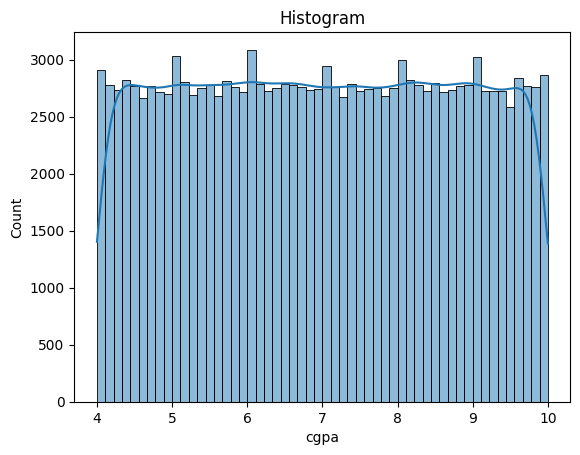

In [300]:
sns.histplot(df["cgpa"],kde=True)
plt.title("Histogram")

In [301]:
# The histogram looks fairly uniform/flat across the range (around 4 to 10), rather than forming a bell-shaped curve.
# Skewness: It appears approximately symmetric, with no strong left or right skew.
# Kurtosis: The distribution is platykurtic (flatter than normal), meaning it has lighter tails and less peak compared 
# to a normal distribution.

2. Plot a boxplot of cgpa by stress_level. What insights can you derive about the
relationship between stress and academic performance?

Text(0.5, 1.0, 'Boxplot of Stress level and Cgpa')

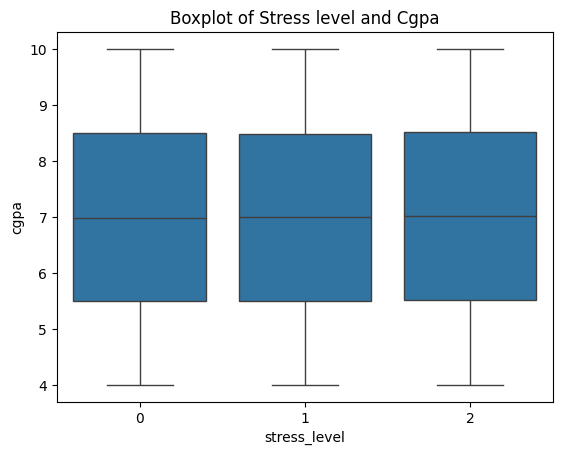

In [302]:
sns.boxplot(x="stress_level" , y="cgpa",data=df)
plt.title("Boxplot of Stress level and Cgpa")

In [303]:
# From the result of the boxplot we can say that it does not impact it significantly.

3. Create a bar plot showing average anxiety_score by gender. Which gender shows
higher anxiety, and does this align with common expectations?

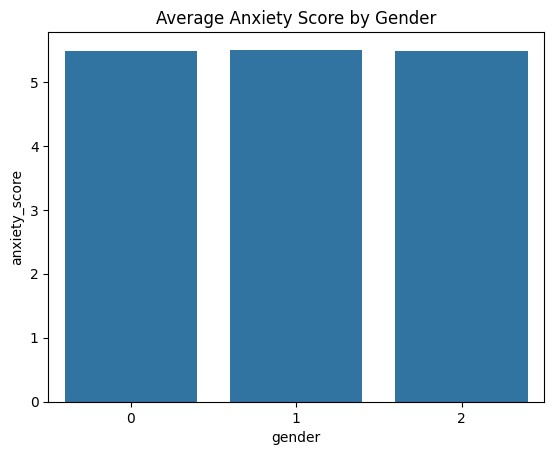

In [304]:
avg_anxiety = df.groupby('gender')['anxiety_score'].mean().reset_index()

sns.barplot(x='gender', y='anxiety_score', data=avg_anxiety)
plt.title("Average Anxiety Score by Gender")
plt.show()

In [305]:
# Each gender shows pretty much the same anxiety score.

4. Plot a scatter plot with daily_study_hours on x-axis and cgpa on y-axis, colored by
sleep_quality. What patterns emerge?

Text(0.5, 1.0, 'Scatter plot')

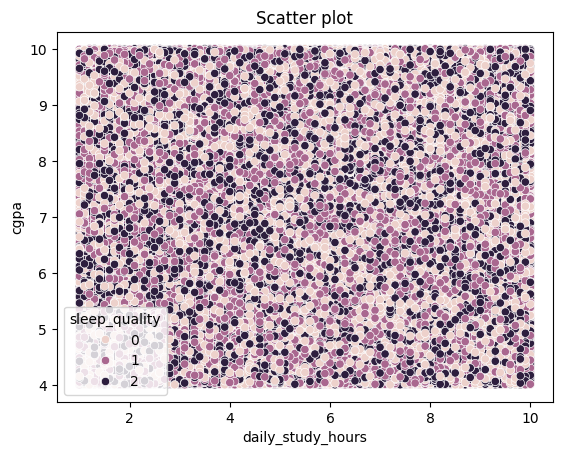

In [306]:
sns.scatterplot(x="daily_study_hours",y="cgpa",data=df,hue="sleep_quality")
plt.title("Scatter plot")

In [307]:
# It is evenly distributed all over the plot.

5. Create a grouped bar chart showing the count of students in each burnout_level across
different course types. Which course has the highest burnout proportion?

Text(0.5, 1.0, 'Count of Students by Burnout Level Across Course Types')

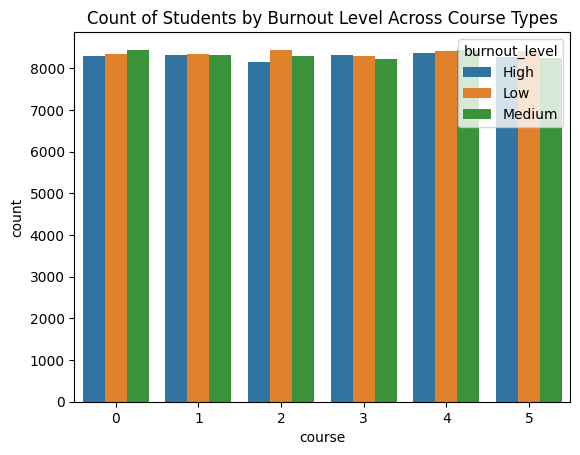

In [308]:
grouped_data = df.groupby(['course', 'burnout_level']).size().reset_index(name='count')
sns.barplot(data=grouped_data, x='course', y='count', hue='burnout_level')

plt.title('Count of Students by Burnout Level Across Course Types')

6. Plot the distribution of screen_time_hours. Identify any extreme values and relate them
to depression_score.


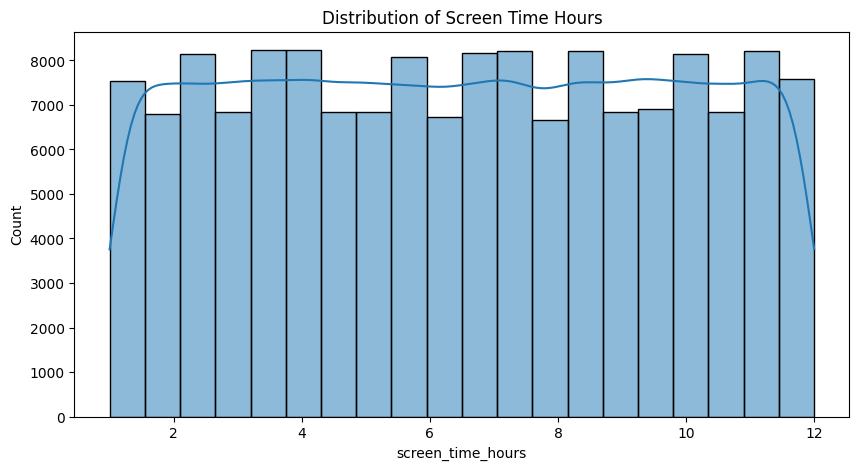

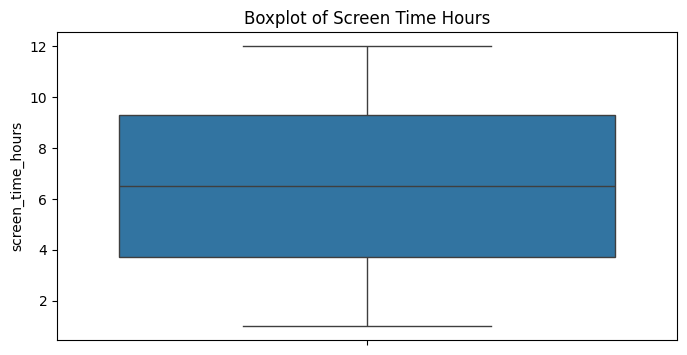

In [309]:
plt.figure(figsize=(10,5))
sns.histplot(df['screen_time_hours'], bins=20, kde=True)
plt.title('Distribution of Screen Time Hours')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(y=df['screen_time_hours'])
plt.title('Boxplot of Screen Time Hours')
plt.show()

7. Create a violin plot of cgpa by internet_quality. What does this suggest about internet
quality's impact on academics?


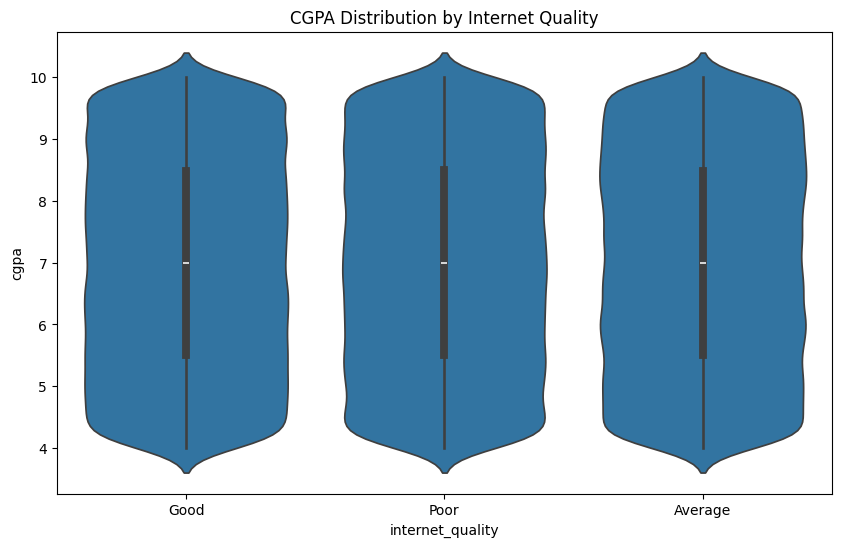

In [310]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='internet_quality', y='cgpa', inner='box')

plt.title('CGPA Distribution by Internet Quality')
plt.show()

8. Plot a heatmap of the correlation matrix for all numerical variables. Which features are
most correlated with cgpa? With anxiety_score?


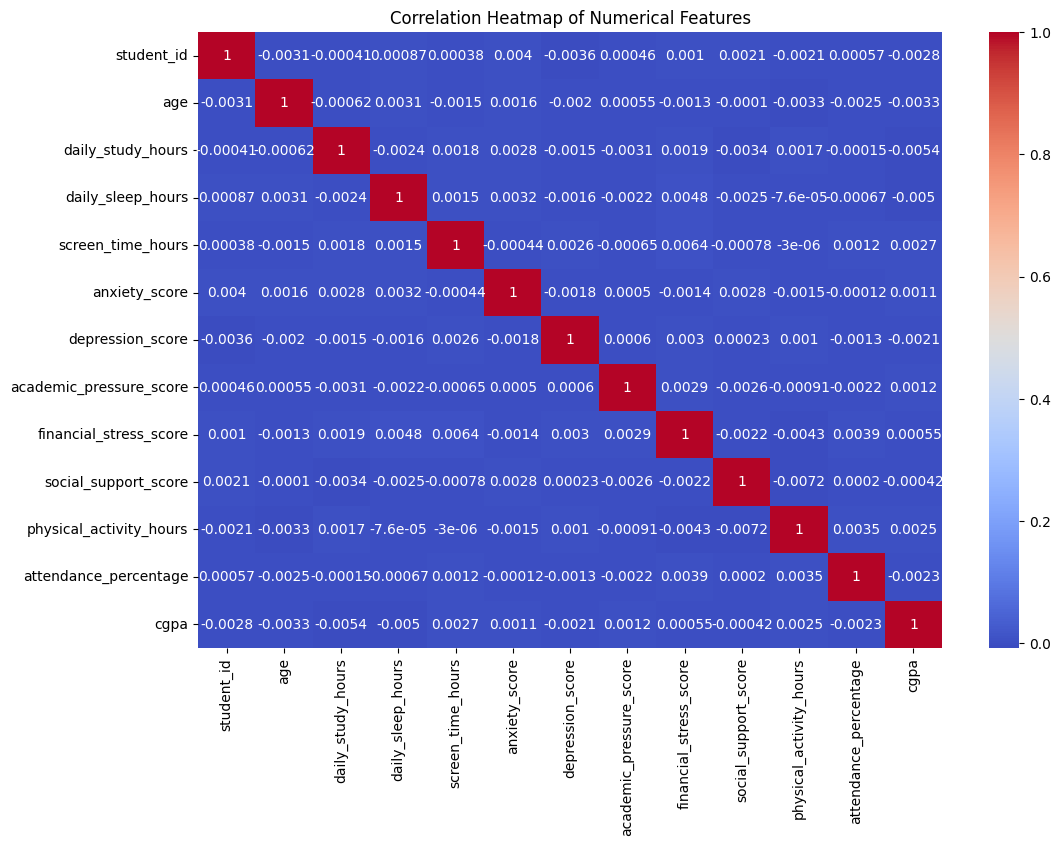

In [311]:
numerical_cols = ['student_id', 'age', 'daily_study_hours', 'daily_sleep_hours', 
                  'screen_time_hours', 'anxiety_score', 'depression_score', 
                  'academic_pressure_score', 'financial_stress_score', 
                  'social_support_score', 'physical_activity_hours', 
                  'attendance_percentage', 'cgpa']

corr = df[numerical_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [312]:
# Screen_time_hours are related the most with cgpa.
# Daily_sleep_hours are related the most with anxiety_score.

9. Create a pairplot for daily_study_hours, screen_time_hours, cgpa, and
anxiety_score. Which relationships appear non-linear?


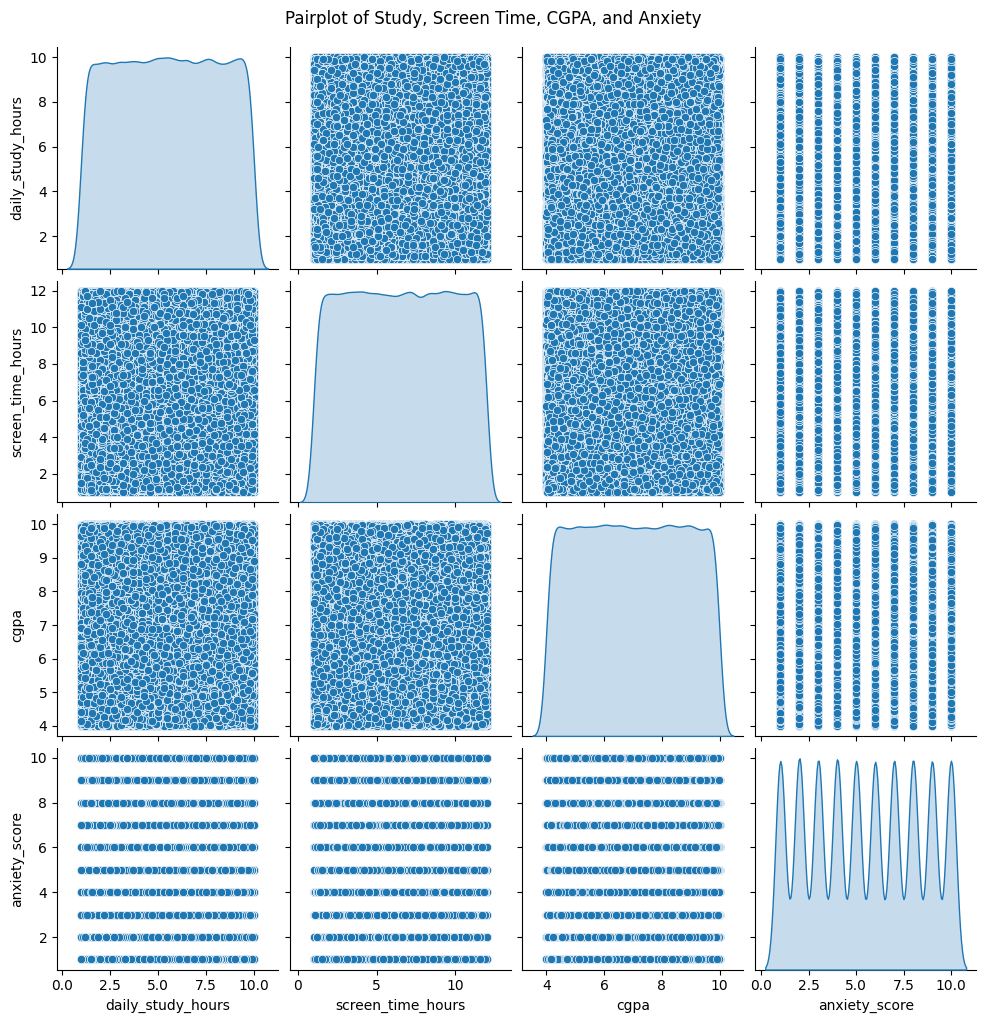

In [313]:
cols = ['daily_study_hours', 'screen_time_hours', 'cgpa', 'anxiety_score']

sns.pairplot(df[cols], diag_kind='kde')
plt.suptitle('Pairplot of Study, Screen Time, CGPA, and Anxiety', y=1.02)
plt.show()

In [314]:
# Overall, no significant non-linear relationships are observed.

10. Boxplot of academic_pressure_score by burnout_level. Is there a statistically
significant difference visible?

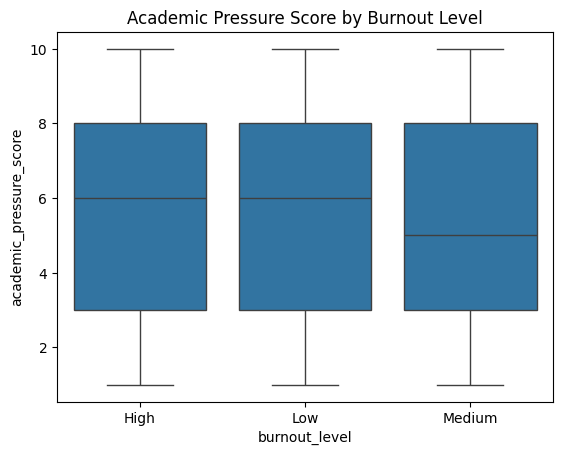

In [315]:
sns.boxplot(data=df, x='burnout_level', y='academic_pressure_score')

plt.title('Academic Pressure Score by Burnout Level')
plt.show()

In [316]:
# No, there is no statistically significant difference visible.

In [317]:
print(df['year'].unique())
print(df['sleep_quality'].unique())
print(df['internet_quality'].unique())

<StringArray>
['1st', '3rd', '4th', '2nd']
Length: 4, dtype: str
[1 0 2]
<StringArray>
['Good', 'Poor', 'Average']
Length: 3, dtype: str


In [318]:
df['year'] = df['year'].map({'1st':1, '2nd':2, '3rd':3, '4th':4})
df['sleep_quality'] = df['sleep_quality'].map({'Poor':0, 'Average':1, 'Good':2})
df['internet_quality'] = df['internet_quality'].map({'Poor':0, 'Average':1, 'Good':2})

In [319]:
df['sleep_quality'] =  df['sleep_quality'].fillna(1, inplace=True) 

C:\Users\Laptop Links\AppData\Local\Temp\ipykernel_18188\711951732.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['sleep_quality'] =  df['sleep_quality'].fillna(1, inplace=True)


Section 4: Model Building — Binary Classification

Target Variable Creation
Create a binary target variable high_burnout where:
● 1 if burnout_level = "High"
● 0 if burnout_level = "Low" or "Medium"
Explain why you chose this binarization.

In [320]:
df['high_burnout'] = df['burnout_level'].astype(str).str.strip().str.lower().map({
    'high': 1,
    'medium': 0,
    'low': 0
})

In [321]:
# The burnout_level variable was converted into a binary target variable high_burnout, where 'High' burnout is labeled 
# as 1 and both 'Low' and 'Medium' are labeled as 0. This binarization simplifies the problem into a binary 
# classification task, making it easier to model and interpret.

Feature Selection
a. Which columns will you use as features (X) for prediction? Justify your selection.

In [322]:
X = df.drop(columns=['burnout_level', 'high_burnout', 'student_id'])

In [323]:
# The selected features include demographic, behavioral, academic, and psychological factors that are likely to 
# influence student burnout. Variables such as daily_study_hours, academic_pressure_score, and attendance_percentage 
# capture academic workload and engagement, while anxiety_score and depression_score reflect mental health status. 
#Lifestyle-related features like screen_time_hours, sleep_hours, and physical_activity_hours provide insights into 
# student habits, which are known to impact stress and burnout.

b. Which column is the target (y)?

In [324]:
y = df['high_burnout']

c. Do you need to drop any columns to prevent data leakage? Identify them

Train-Test Split


a. Split the data into training and testing sets with 80–20 ratio and random_state = 42. Why is
random_state important?

In [325]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [326]:
# What it does

# When you split your dataset into training and testing sets, most splitting methods pick rows randomly.

# Without random_state, every time you run the split, you get different rows in training and testing sets.
# With random_state set to a fixed number (like 42), the "random" selection is reproducible.

b. What is the purpose of splitting the dataset before training?

In [327]:
# Splitting the dataset ensures the model learns from one set (training) and is tested on unseen data (testing), 
# which helps evaluate its real-world performance and prevents overfitting.

Model Initialization & Training

a. Initialize a Logistic Regression model with max_iter = 1000. Why might you need to increase
max_iter?


In [328]:
log_reg = LogisticRegression(max_iter=1000)

b. Fit the model on the training data. What is the training accuracy score?

In [329]:
X

,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality
0,23.0,1,3,1,4.3,6.8,6.1,2,10.0,3.0,4.0,2.0,6.0,1.8,1.0,66.5,9.63,2
1,20.0,1,3,3,1.4,4.7,3.0,2,2.0,10.0,8.0,5.0,9.0,1.9,1.0,55.8,6.04,0
2,24.0,0,1,4,3.7,4.8,1.5,0,2.0,7.0,8.0,6.0,3.0,0.8,1.0,85.0,8.31,2
3,21.0,1,2,4,1.6,6.7,7.0,2,3.0,3.0,4.0,9.0,9.0,0.7,1.0,89.1,5.95,2
4,23.0,2,2,4,2.0,6.7,5.4,2,7.0,7.0,6.0,4.0,4.0,1.7,1.0,58.7,8.51,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,24.0,0,2,3,1.6,8.2,11.3,1,9.0,9.0,5.0,3.0,10.0,2.0,1.0,54.2,7.82,2
149996,25.0,1,1,3,9.9,4.8,1.6,2,10.0,3.0,10.0,10.0,2.0,0.1,1.0,53.6,7.19,1
149997,22.0,1,3,1,1.4,4.4,4.6,2,10.0,8.0,6.0,4.0,7.0,1.6,1.0,90.7,9.78,1
149998,19.0,1,2,3,1.5,4.3,1.1,1,8.0,6.0,5.0,7.0,4.0,1.1,1.0,83.9,9.88,1


In [330]:
y.value_counts()

high_burnout
0    100234
1     49766
Name: count, dtype: int64

In [331]:
log_reg.fit(X_train, y_train)

train_accuracy = log_reg.score(X_train, y_train)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.6687916666666667


Section 5: Model Evaluation


Predictions & Metrics


a. Predict on the test set and calculate accuracy, precision, recall, and F1-score.

In [332]:
y_pred = log_reg.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.6659666666666667
Precision: 0.0
Recall: 0.0
F1-score: 0.0


c:\Users\Laptop Links\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


b. Generate and interpret the confusion matrix

In [333]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[19979     0]
 [10021     0]]


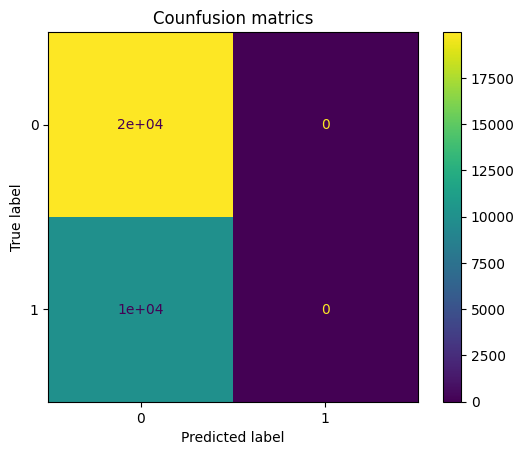

In [334]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Counfusion matrics")
plt.show()

ROC-AUC Analysis

a. Plot the ROC curve and calculate the AUC score. What does this tell you about model
discriminative ability?

In [335]:
y_prob = log_reg.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.4996901121988886


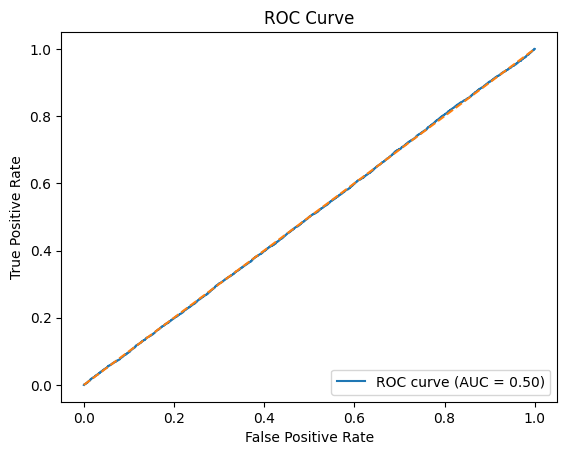

In [336]:
plt.figure()
plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

b. If AUC is below 0.7, what might be the reasons?


In [337]:
# If AUC < 0.7, it means the model has poor discriminative ability.

Classification Report Analysis


Provide and interpret the classification report. Which class (high_burnout = 0 or 1) is the model
better at predicting? Why might this be happening?

In [338]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80     19979
           1       0.00      0.00      0.00     10021

    accuracy                           0.67     30000
   macro avg       0.33      0.50      0.40     30000
weighted avg       0.44      0.67      0.53     30000



c:\Users\Laptop Links\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Laptop Links\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Laptop Links\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [339]:
# The model is much better at predicting class 0 (non-high burnout)
# It completely fails for class 1 (high burnout)

Section 6: Model Interpretation & Critical Thinking

Coefficient Analysis

a. Extract and interpret the coefficients of the logistic regression model. Which features have the
strongest positive and negative influence on predicting high burnout?

In [340]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_reg.coef_[0]
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
coef_df

print("Top Positive Influence:")
print(coef_df.head())

print("\nTop Negative Influence:")
print(coef_df.tail())

Top Positive Influence:
                    Feature  Coefficient
17         internet_quality     0.010521
7              stress_level     0.005674
10  academic_pressure_score     0.003901
9          depression_score     0.001165
11   financial_stress_score     0.000548

Top Negative Influence:
                    Feature  Coefficient
16                     cgpa    -0.002110
1                    gender    -0.002345
5         daily_sleep_hours    -0.007438
13  physical_activity_hours    -0.012311
14            sleep_quality    -0.311730


In [341]:
# internet_quality has the top positive influence.
# cgpa has the top negative influence.

b. How would you explain the impact of academic_pressure_score on burnout odds to a
non-technical stakeholder?


In [342]:
coef_df[coef_df['Feature'] == 'academic_pressure_score']

,Feature,Coefficient
10,academic_pressure_score,0.003901


In [343]:
np.exp(0.003901)

np.float64(1.0039086188042636)

In [344]:
# A 1-unit increase in academic pressure makes high burnout 1.0039 times more likely.